# Fandango website's Conspiracy - Movie reviews investigation - Data Analysis
## Overview

If you are planning on going out to see a movie, how well can you trust online reviews and ratings? *Especially* if the same company showing the rating *also* makes money by selling movie tickets. Do they have a bias towards rating movies higher than they should be rated?

### Goal:

**The goal is to determine if Fandango's ratings in 2015 had a bias towards rating movies better to sell more tickets.**

### The Data

There are two csv files, one with Fandango Stars and Displayed Ratings, and the other with aggregate data for movie ratings from other sites, like Metacritic,IMDB, and Rotten Tomatoes.

-----

`all_sites_scores.csv` contains every film that has a Rotten Tomatoes rating, a RT User rating, a Metacritic score, a Metacritic User score, and IMDb score, and at least 30 fan reviews on Fandango. The data from Fandango was pulled on Aug. 24, 2015.

Column | Definition
--- | -----------
FILM | The film in question
RottenTomatoes | The Rotten Tomatoes Tomatometer score  for the film
RottenTomatoes_User | The Rotten Tomatoes user score for the film
Metacritic | The Metacritic critic score for the film
Metacritic_User | The Metacritic user score for the film
IMDB | The IMDb user score for the film
Metacritic_user_vote_count | The number of user votes the film had on Metacritic
IMDB_user_vote_count | The number of user votes the film had on IMDb

----
----

#### fandango_scape.csv

`fandango_scrape.csv` contains every film 538 pulled from Fandango.

Column | Definiton
--- | ---------
FILM | The movie
STARS | Number of stars presented on Fandango.com
RATING |  The Fandango ratingValue for the film, as pulled from the HTML of each page. This is the actual average score the movie obtained.
VOTES | number of people who had reviewed the film at the time we pulled it.

**Importing the required libraries**

In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploring Fandango Displayed Scores versus True User Ratings

Let's first explore the Fandango ratings to see if our analysis agrees with the article's conclusion.

In [2]:
# Reading the fandango data
fandango = pd.read_csv(r"D:\Python\fandango_scrape.csv")

In [3]:
# Checking if the data load has sucessfully worked
fandango.head()

,FILM,STARS,RATING,VOTES
0,Fifty Shades of Grey (2015),4.0,3.9,34846
1,Jurassic World (2015),4.5,4.5,34390
2,American Sniper (2015),5.0,4.8,34085
3,Furious 7 (2015),5.0,4.8,33538
4,Inside Out (2015),4.5,4.5,15749


In [5]:
# Getting some basic info regarding our dataset
fandango.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   FILM    504 non-null    object 
 1   STARS   504 non-null    float64
 2   RATING  504 non-null    float64
 3   VOTES   504 non-null    int64  
dtypes: float64(2), int64(1), object(1)
memory usage: 15.9+ KB


In [6]:
# Checking out basic stats of our data
fandango.describe()

,STARS,RATING,VOTES
count,504.000000,504.000000,504.000000
mean,3.558532,3.375794,1147.863095
std,1.563133,1.491223,3830.583136
min,0.000000,0.000000,0.000000
25%,3.500000,3.100000,3.000000
50%,4.000000,3.800000,18.500000
75%,4.500000,4.300000,189.750000
max,5.000000,5.000000,34846.000000


**Let's explore the relationship between popularity of a film and its rating. This will be done by creating a scatterplot showing the relationship between rating and votes.**

<Axes: xlabel='RATING', ylabel='VOTES'>

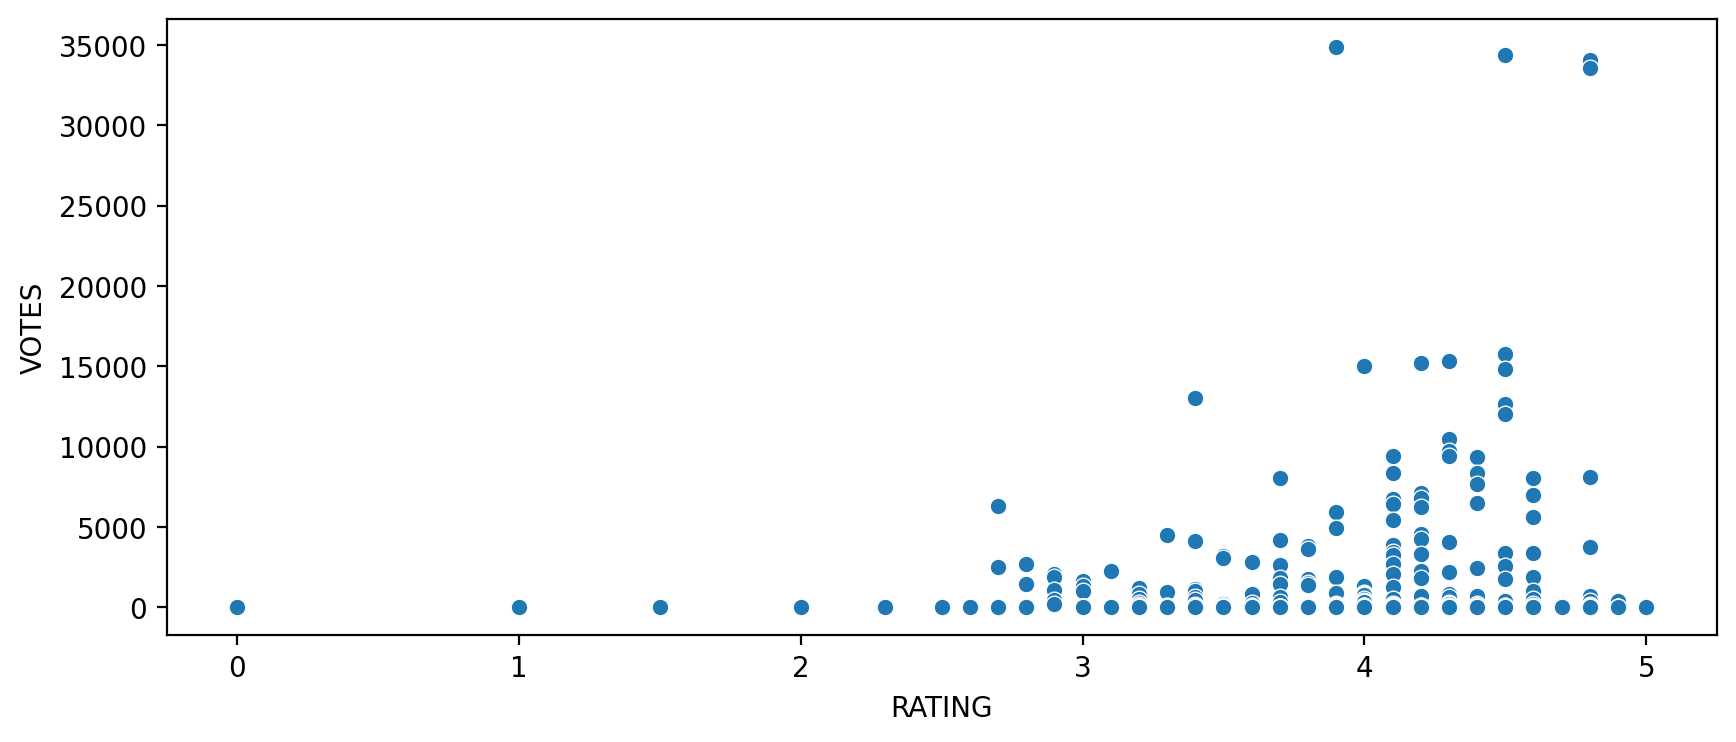

In [8]:
# Editing the visual size and the clarity
plt.figure(figsize = (10, 4), dpi = 200)

# Creating the scatter plot
sns.scatterplot(data = fandango, y = 'VOTES', x = 'RATING')

-----
**Calculating the correlation between the columns**

In [10]:
fandango.corr(numeric_only = True)

,STARS,RATING,VOTES
STARS,1.000000,0.994696,0.164218
RATING,0.994696,1.000000,0.163764
VOTES,0.164218,0.163764,1.000000


**Point to notice: The rating and the stars are not perfectly correlated which means that there is some difference in how ratings and stars are reported**

-----
**I need the year column to be separate. I noticed that every row in the FILM title column has the same format:**

    Film Title Name (Year)
    
**I will create a new column that is able to strip the year from the title strings and set this new column as YEAR**

In [12]:
# Testing out if my technique works in a sample format
title = 'Film Title Name (Year)'

In [128]:
# Splitting the string first, then using replace to get rid of the closing parenthesis
title.split('(')[-1].replace(')', '')

'Year'

In [17]:
# Now that my technique works, I will use this in the actual dataset. I will use lambda to go over each line of the string column
fandango['YEAR'] = fandango['FILM'].apply(lambda title : title.split('(')[-1].replace(')', ''))
fandango.head()

,FILM,STARS,RATING,VOTES,YEAR
0,Fifty Shades of Grey (2015),4.0,3.9,34846,2015
1,Jurassic World (2015),4.5,4.5,34390,2015
2,American Sniper (2015),5.0,4.8,34085,2015
3,Furious 7 (2015),5.0,4.8,33538,2015
4,Inside Out (2015),4.5,4.5,15749,2015


-----
**I'm curious - How many movies are in the Fandango DataFrame per year?**

In [18]:
fandango['YEAR'].value_counts()

YEAR
2015    478
2014     23
2016      1
1964      1
2012      1
Name: count, dtype: int64

**Looks like most of the movies are from 2015, some from 2014 and weirdly a movie from 1964 as well... Interesting**

**Let's visualize the count of movies per year**

<Axes: xlabel='YEAR', ylabel='count'>

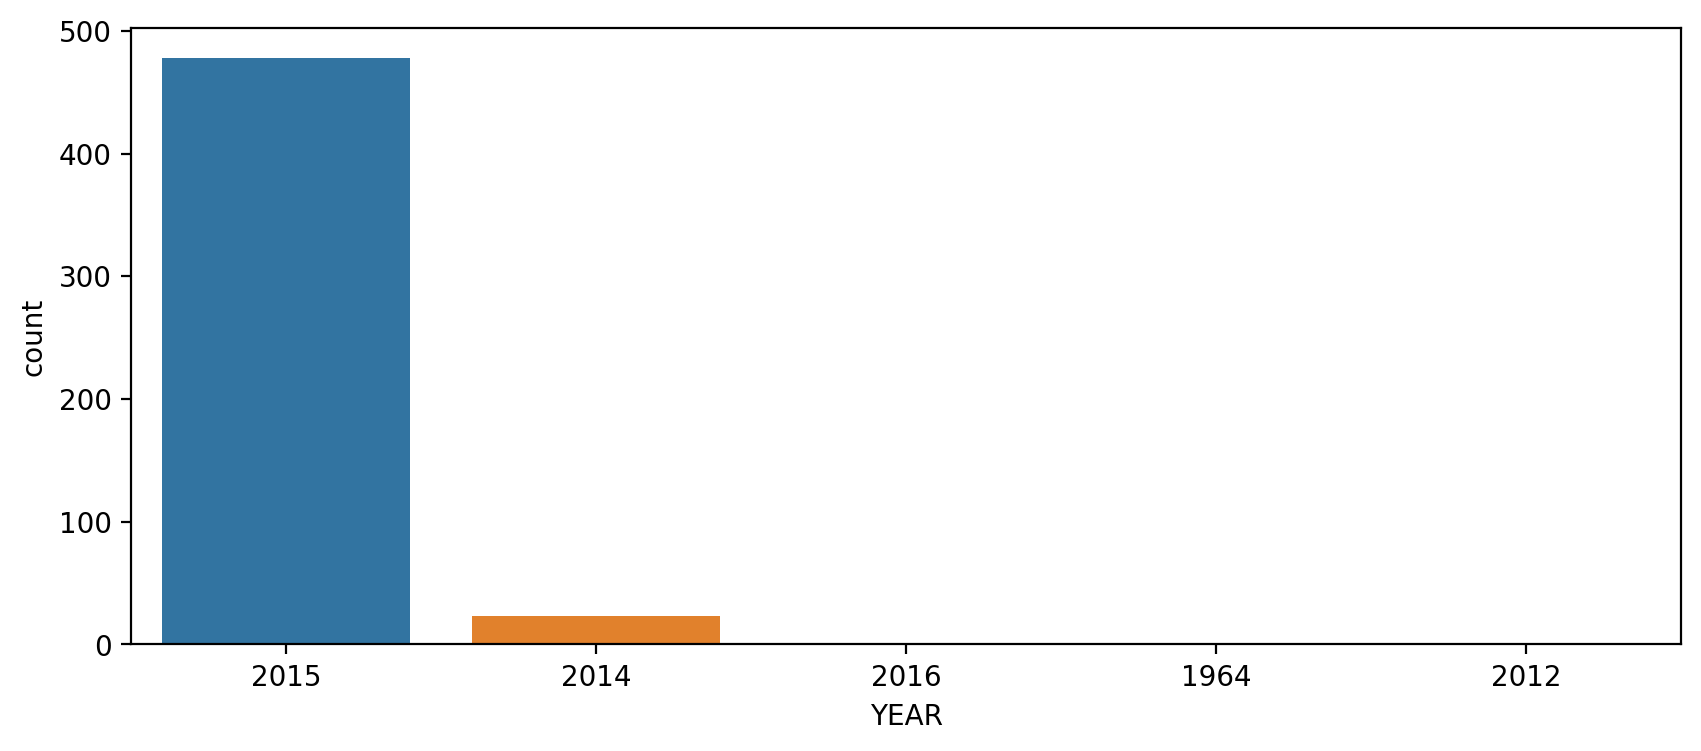

In [21]:
# Editing the visual size and the clarity
plt.figure(figsize = (10, 4), dpi = 200)

# Using countplot as we need to visualize the count of movies per year
sns.countplot(data = fandango, x = 'YEAR', hue = 'YEAR')

-----
**I want to find out what are the 10 movies with the highest number of votes?**

In [24]:
fandango.nlargest(10, 'VOTES')

,FILM,STARS,RATING,VOTES,YEAR
0,Fifty Shades of Grey (2015),4.0,3.9,34846,2015
1,Jurassic World (2015),4.5,4.5,34390,2015
2,American Sniper (2015),5.0,4.8,34085,2015
3,Furious 7 (2015),5.0,4.8,33538,2015
4,Inside Out (2015),4.5,4.5,15749,2015
5,The Hobbit: The Battle of the Five Armies (2014),4.5,4.3,15337,2014
6,Kingsman: The Secret Service (2015),4.5,4.2,15205,2015
7,Minions (2015),4.0,4.0,14998,2015
8,Avengers: Age of Ultron (2015),5.0,4.5,14846,2015
9,Into the Woods (2014),3.5,3.4,13055,2014


-----
**I wonder if there are any movies have zero votes...**

In [28]:
# Looks like there are! They are not required for our analysis, I will remove these next
print((fandango['VOTES'] == 0).sum())

69


**I will create a DataFrame of only reviewed films by removing any films that have zero votes.**

In [29]:
fan_reviewed = fandango[fandango['VOTES'] > 0]

# Checking if that worked
fan_reviewed.head()

,FILM,STARS,RATING,VOTES,YEAR
0,Fifty Shades of Grey (2015),4.0,3.9,34846,2015
1,Jurassic World (2015),4.5,4.5,34390,2015
2,American Sniper (2015),5.0,4.8,34085,2015
3,Furious 7 (2015),5.0,4.8,33538,2015
4,Inside Out (2015),4.5,4.5,15749,2015


----

**As noted in the article, due to HTML and star rating displays, the true user rating may be slightly different than the rating shown to a user. Let's visualize this difference in distributions.**

**I will create multiple overlapping KDE plots that displays the distribution of ratings that are displayed (STARS) versus what the true rating was from votes (RATING).**

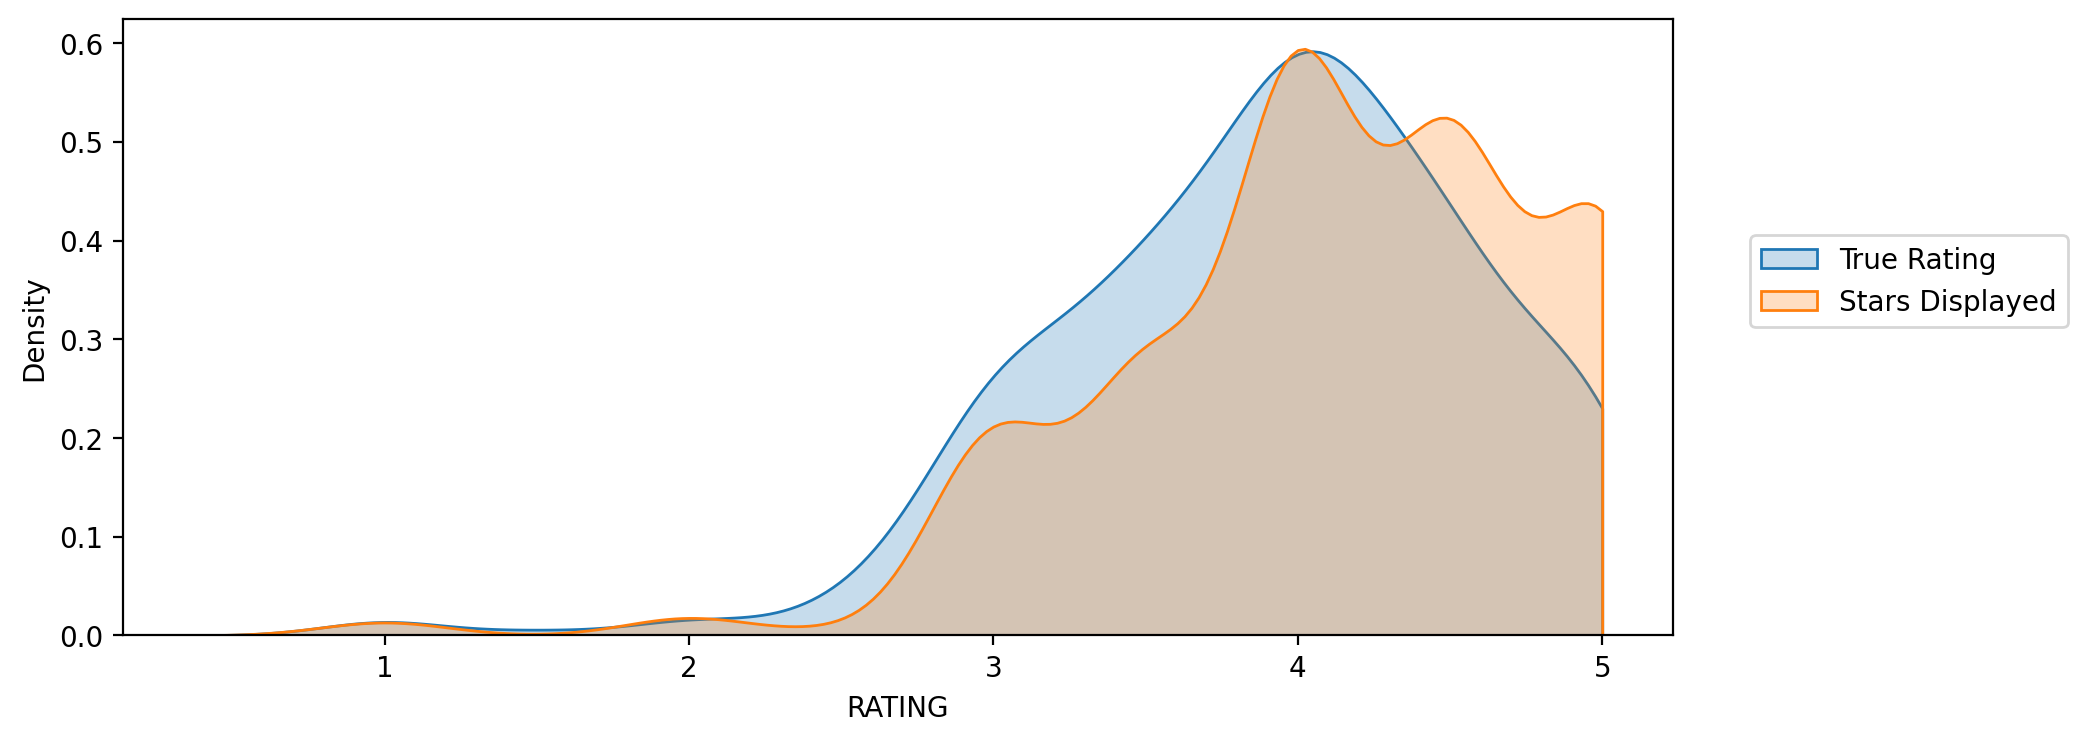

In [38]:
# Adjusting the size and clarity of the visual
plt.figure(figsize = (10, 4), dpi = 200)

# Overlapping multiple kde plots to visualize the difference. Clip was used as the ratings cannot go above 5
sns.kdeplot(data = fan_reviewed, x = 'RATING', clip = [0, 5], fill = True, label = 'True Rating')
sns.kdeplot(data = fan_reviewed, x = 'STARS', clip = [0, 5], fill = True, label = 'Stars Displayed')

# Moving the legend so that it does not interfere with the visual
plt.legend(loc = (1.05, 0.5))

**Let's now actually quantify this discrepancy. I will create a new column of the different between STARS displayed versus true RATING.**

In [49]:
fan_reviewed['STARS_DIFF'] = round(fan_reviewed['STARS'] - fan_reviewed['RATING'], 1)

# Testing if the above worked
fan_reviewed.head()

C:\Users\forwa\AppData\Local\Temp\ipykernel_35588\3264051412.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fan_reviewed['STARS_DIFF'] = round(fan_reviewed['STARS'] - fan_reviewed['RATING'], 1)


,FILM,STARS,RATING,VOTES,YEAR,STARS_DIFF
0,Fifty Shades of Grey (2015),4.0,3.9,34846,2015,0.1
1,Jurassic World (2015),4.5,4.5,34390,2015,0.0
2,American Sniper (2015),5.0,4.8,34085,2015,0.2
3,Furious 7 (2015),5.0,4.8,33538,2015,0.2
4,Inside Out (2015),4.5,4.5,15749,2015,0.0


**I will create a count plot to display the number of times a certain difference occurs:**

C:\Users\forwa\AppData\Local\Temp\ipykernel_35588\2727622539.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = fan_reviewed, x = 'STARS_DIFF', palette = 'magma')


<Axes: xlabel='STARS_DIFF', ylabel='count'>

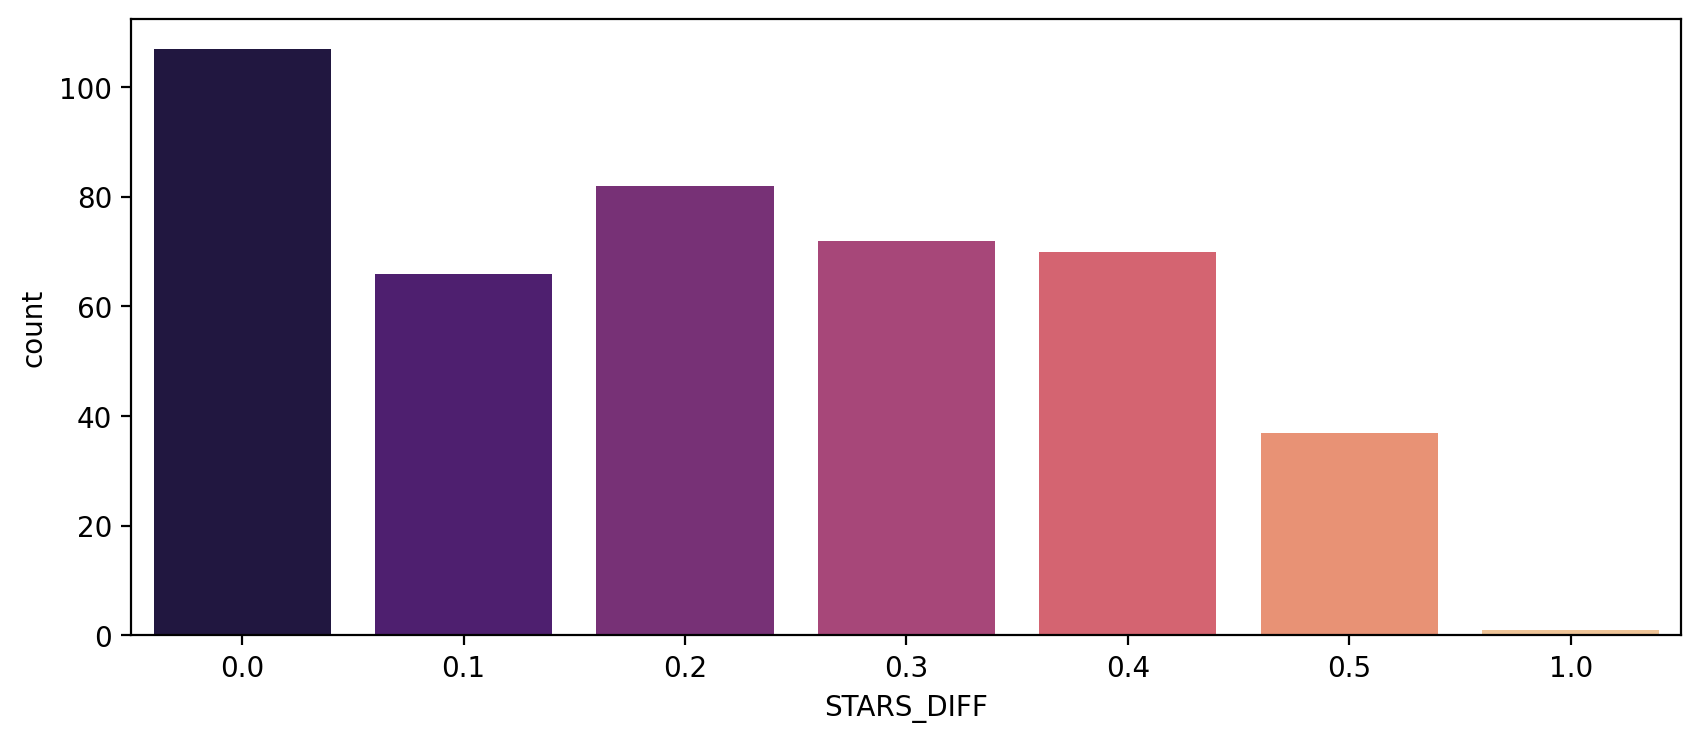

In [54]:
plt.figure(figsize = (10, 4), dpi = 200)
sns.countplot(data = fan_reviewed, x = 'STARS_DIFF', palette = 'magma')

**We can see from the plot that one movie was displaying over a 1 star difference than its true rating! What movie had this close to 1 star differential?**

In [129]:
# Finding out which movie that that unusual differential
fan_reviewed[fan_reviewed['STARS_DIFF'] == 1.0]

,FILM,STARS,RATING,VOTES,YEAR,STARS_DIFF
381,Turbo Kid (2015),5.0,4.0,2,2015,1.0


----
## Comparison of Fandango Ratings to Other Sites

Let's now compare the scores from Fandango to other movies sites and see how they compare.

In [58]:
# Reading in the data which contains the data from all the sites
all_sites = pd.read_csv(r"D:\Python\all_sites_scores.csv")

**Exploring the DataFrame columns, info, description.**

In [59]:
all_sites.head()

,FILM,RottenTomatoes,RottenTomatoes_User,Metacritic,Metacritic_User,IMDB,Metacritic_user_vote_count,IMDB_user_vote_count
0,Avengers: Age of Ultron (2015),74,86,66,7.1,7.8,1330,271107
1,Cinderella (2015),85,80,67,7.5,7.1,249,65709
2,Ant-Man (2015),80,90,64,8.1,7.8,627,103660
3,Do You Believe? (2015),18,84,22,4.7,5.4,31,3136
4,Hot Tub Time Machine 2 (2015),14,28,29,3.4,5.1,88,19560


In [60]:
all_sites.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146 entries, 0 to 145
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   FILM                        146 non-null    object 
 1   RottenTomatoes              146 non-null    int64  
 2   RottenTomatoes_User         146 non-null    int64  
 3   Metacritic                  146 non-null    int64  
 4   Metacritic_User             146 non-null    float64
 5   IMDB                        146 non-null    float64
 6   Metacritic_user_vote_count  146 non-null    int64  
 7   IMDB_user_vote_count        146 non-null    int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 9.3+ KB


In [61]:
all_sites.describe()

,RottenTomatoes,RottenTomatoes_User,Metacritic,Metacritic_User,IMDB,Metacritic_user_vote_count,IMDB_user_vote_count
count,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000
mean,60.849315,63.876712,58.808219,6.519178,6.736986,185.705479,42846.205479
std,30.168799,20.024430,19.517389,1.510712,0.958736,316.606515,67406.509171
min,5.000000,20.000000,13.000000,2.400000,4.000000,4.000000,243.000000
25%,31.250000,50.000000,43.500000,5.700000,6.300000,33.250000,5627.000000
50%,63.500000,66.500000,59.000000,6.850000,6.900000,72.500000,19103.000000
75%,89.000000,81.000000,75.000000,7.500000,7.400000,168.500000,45185.750000
max,100.000000,94.000000,94.000000,9.600000,8.600000,2375.000000,334164.000000


### Rotten Tomatoes

Let's first take a look at Rotten Tomatoes. RT has two sets of reviews, their critics reviews (ratings published by official critics) and user reviews. 

**I will create a scatterplot to explore the relationship between RT Critic reviews and RT User reviews.**

<Axes: xlabel='RottenTomatoes', ylabel='RottenTomatoes_User'>

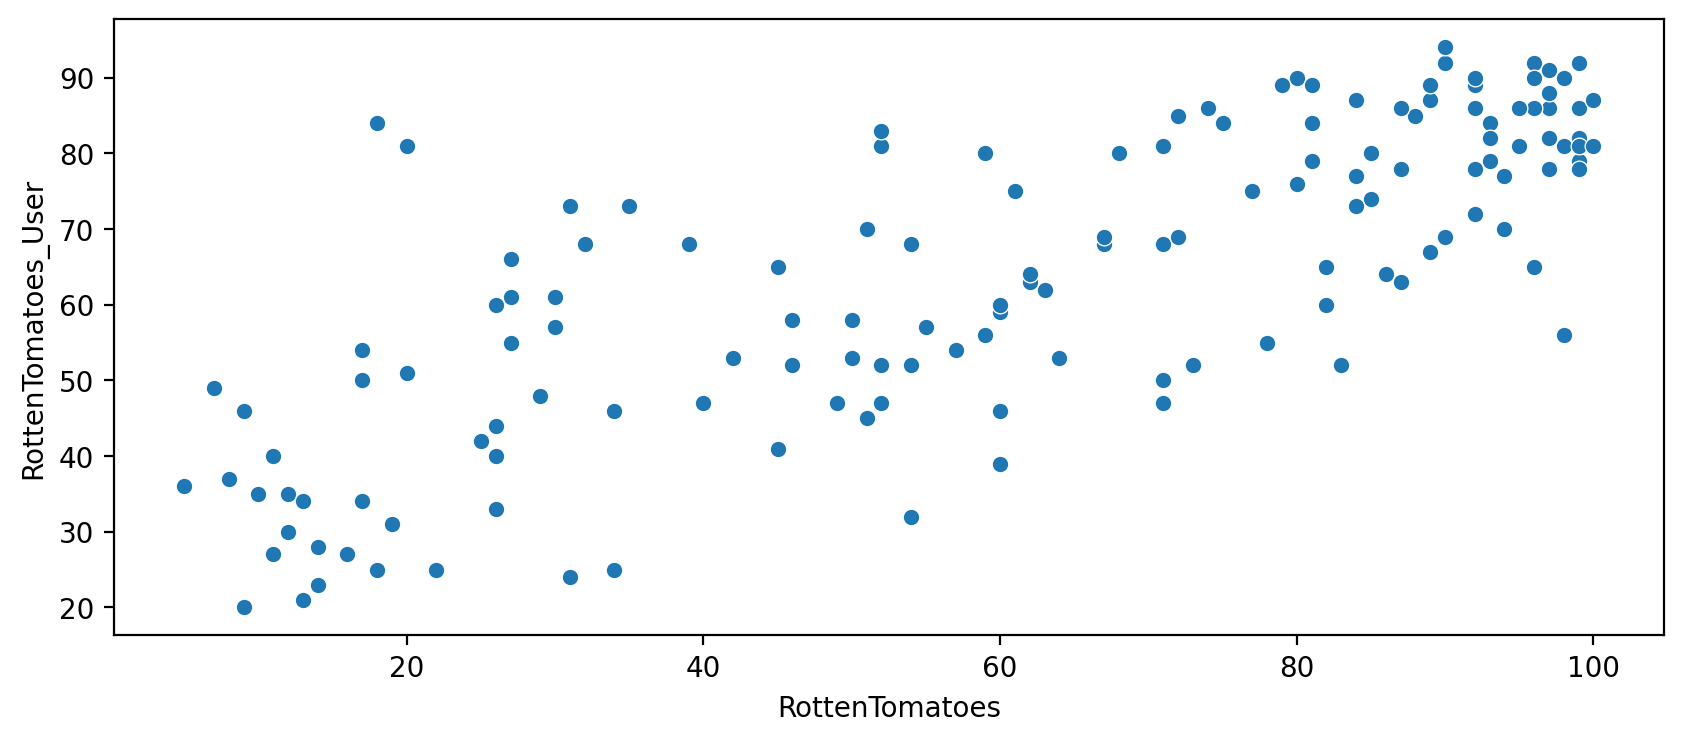

In [65]:
plt.figure(figsize = (10, 4),dpi = 200)
sns.scatterplot(data = all_sites, x = 'RottenTomatoes', y = 'RottenTomatoes_User')

Let's quantify this difference by comparing the critics ratings and the RT User ratings. We will calculate this with RottenTomatoes-RottenTomatoes_User. Note: Rotten_Diff here is Critics - User Score. So values closer to 0 means aggrement between Critics and Users. Larger positive values means critics rated much higher than users. Larger negative values means users rated much higher than critics.

**I will create a new column based off the difference between critics ratings and users ratings for Rotten Tomatoes**

In [67]:
all_sites['Rotten_Diff'] = all_sites['RottenTomatoes'] - all_sites['RottenTomatoes_User']
all_sites['Rotten_Diff']

0     -12
1       5
2     -10
3     -66
4     -14
       ..
141     9
142    15
143    19
144    19
145    24
Name: Rotten_Diff, Length: 146, dtype: int64

I will now compare the overall mean difference. Since we're dealing with differences that could be negative or positive, first take the absolute value of all the differences, then take the mean. This would report back on average to absolute difference between the critics rating versus the user rating.

**Calculating the Mean Absolute Difference between RT scores and RT User scores as described above.**

In [130]:
print(all_sites['Rotten_Diff'].apply(abs).mean())

15.095890410958905


**Ploting the distribution of the differences between RT Critics Score and RT User Score. There should be negative values in this distribution plot.**

<Axes: xlabel='Rotten_Diff', ylabel='Count'>

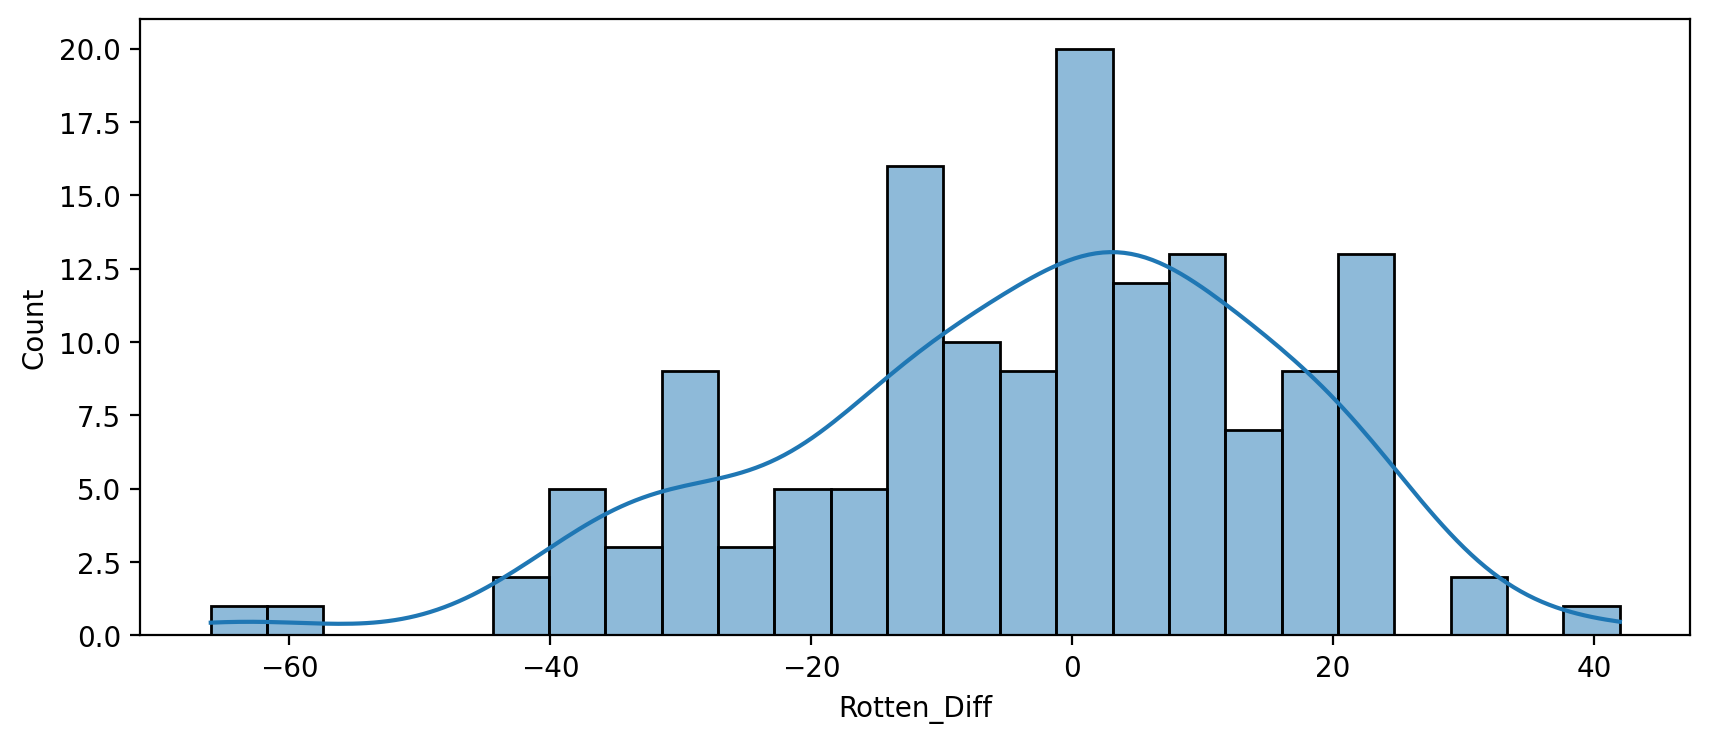

In [131]:
plt.figure(figsize = (10, 4),dpi = 200)
sns.histplot(data = all_sites, x = 'Rotten_Diff', kde = True, bins = 25)

**Now I will create a distribution showing the *absolute value* difference between Critics and Users on Rotten Tomatoes.**

<Axes: xlabel='Rotten_Diff', ylabel='Count'>

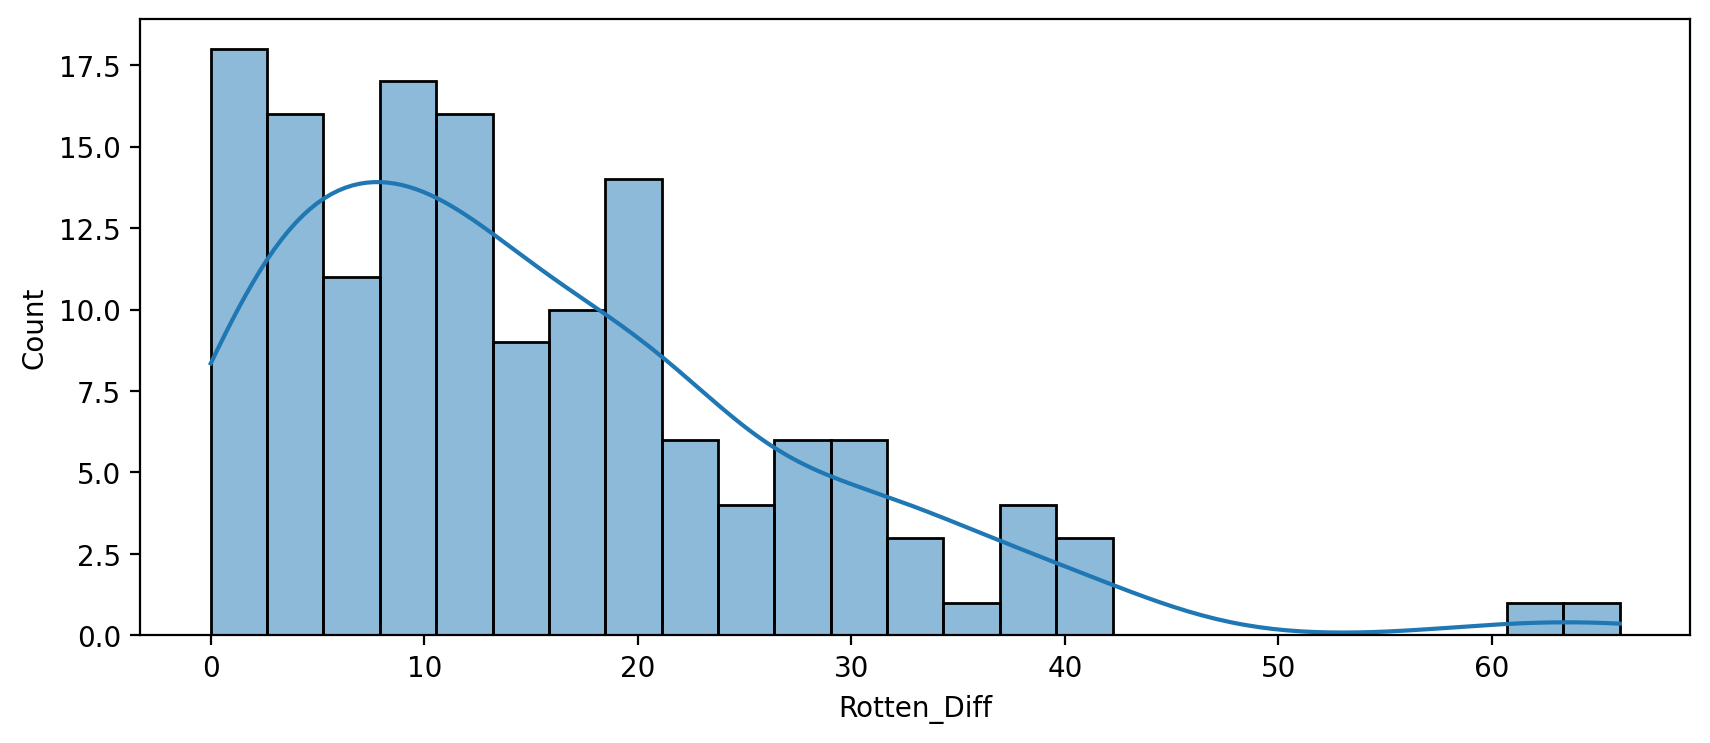

In [72]:
plt.figure(figsize = (10, 4),dpi = 200)
sns.histplot(x = all_sites['Rotten_Diff'].apply(abs), kde = True, bins = 25)

**I will now find out which movies are causing the largest differences. First, I will show the top 5 movies with the largest *negative* difference between Users and RT critics. Since we calculated the difference as Critics Rating - Users Rating, then large negative values imply the users rated the movie much higher on average than the critics did.**

**What are the top 5 movies users rated higher than critics on average?**

In [77]:
all_sites.nsmallest(5, 'Rotten_Diff')[['FILM', 'Rotten_Diff']]

,FILM,Rotten_Diff
3,Do You Believe? (2015),-66
85,Little Boy (2015),-61
105,Hitman: Agent 47 (2015),-42
134,The Longest Ride (2015),-42
125,The Wedding Ringer (2015),-39


**I will now show the top 5 movies critics scores higher than users on average.**

In [78]:
all_sites.nlargest(5, 'Rotten_Diff')[['FILM', 'Rotten_Diff']]

,FILM,Rotten_Diff
69,Mr. Turner (2014),42
112,It Follows (2015),31
115,While We're Young (2015),31
37,Welcome to Me (2015),24
40,I'll See You In My Dreams (2015),24


----
## MetaCritic

Now let's take a quick look at the ratings from MetaCritic. Metacritic also shows an average user rating versus their official displayed rating.

**Displaying a scatterplot of the Metacritic Rating versus the Metacritic User rating.**

<Axes: xlabel='Metacritic', ylabel='Metacritic_User'>

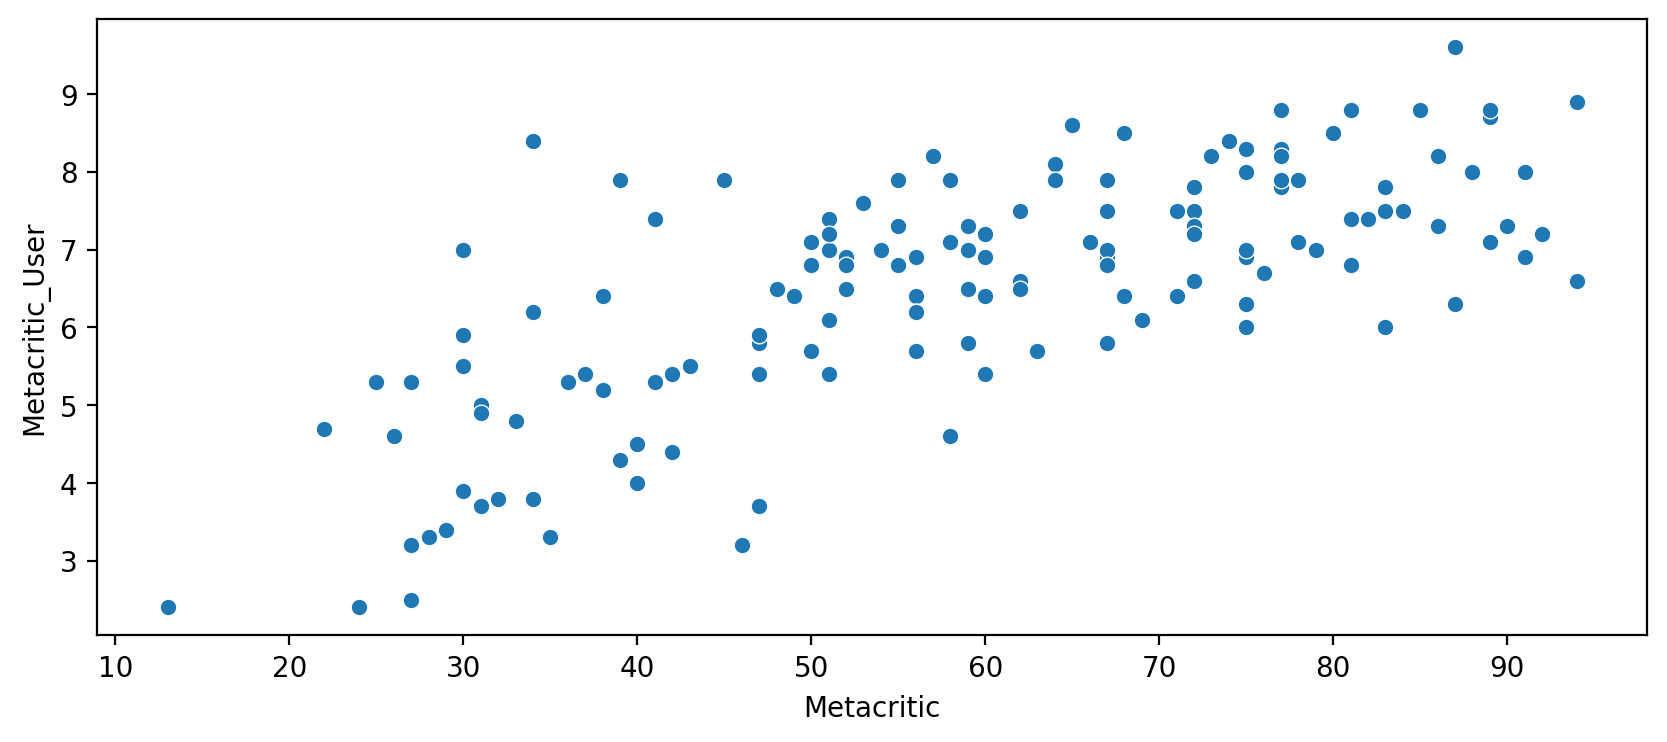

In [79]:
plt.figure(figsize = (10, 4),dpi = 200)
sns.scatterplot(data = all_sites, x = 'Metacritic', y = 'Metacritic_User')

----
## IMDB

Finally let's explore IMDB. Notice that both Metacritic and IMDB report back vote counts. Let's analyze the most popular movies.

**Creating a scatterplot for the relationship between vote counts on MetaCritic versus vote counts on IMDB.**

<Axes: xlabel='Metacritic_user_vote_count', ylabel='IMDB_user_vote_count'>

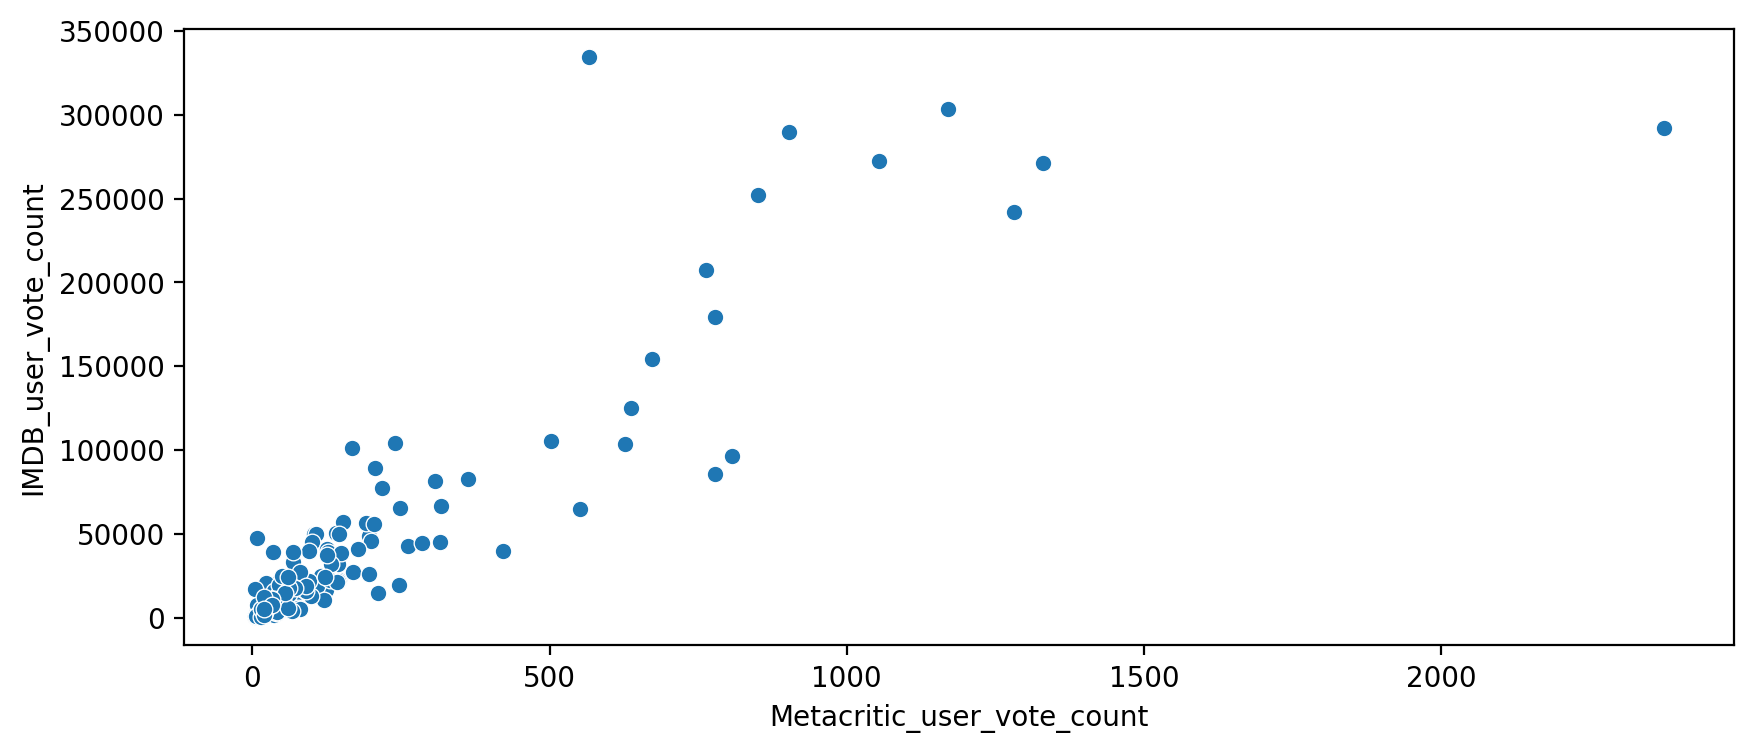

In [80]:
plt.figure(figsize = (10, 4),dpi = 200)
sns.scatterplot(data = all_sites, x = 'Metacritic_user_vote_count', y = 'IMDB_user_vote_count')

**I noticed that there are two outliers here. The movie with the highest vote count on IMDB only has about 500 Metacritic ratings. What is this movie?**

**What movie has the highest IMDB user vote count?**

In [82]:
all_sites.nlargest(1, 'IMDB_user_vote_count')

,FILM,RottenTomatoes,RottenTomatoes_User,Metacritic,Metacritic_User,IMDB,Metacritic_user_vote_count,IMDB_user_vote_count,Rotten_Diff
14,The Imitation Game (2014),90,92,73,8.2,8.1,566,334164,-2


**What movie has the highest Metacritic User Vote count?**

In [83]:
all_sites.nlargest(1, 'Metacritic_user_vote_count')

,FILM,RottenTomatoes,RottenTomatoes_User,Metacritic,Metacritic_User,IMDB,Metacritic_user_vote_count,IMDB_user_vote_count,Rotten_Diff
88,Mad Max: Fury Road (2015),97,88,89,8.7,8.3,2375,292023,9


----
## Fandago Scores vs. All Sites

Finally let's begin to explore whether or not Fandango artificially displays higher ratings than warranted to boost ticket sales.

**I will first combine the Fandango Table with the All Sites table. Not every movie in the Fandango table is in the All Sites table, since some Fandango movies have very little or no reviews. We only want to compare movies that are in both DataFrames, so I will do an *inner* merge to merge together both DataFrames based on the FILM columns.**

In [85]:
df = pd.merge(fandango, all_sites, on = 'FILM', how = 'inner')
df

,FILM,STARS,RATING,VOTES,YEAR,RottenTomatoes,RottenTomatoes_User,Metacritic,Metacritic_User,IMDB,Metacritic_user_vote_count,IMDB_user_vote_count,Rotten_Diff
0,Fifty Shades of Grey (2015),4.0,3.9,34846,2015,25,42,46,3.2,4.2,778,179506,-17
1,Jurassic World (2015),4.5,4.5,34390,2015,71,81,59,7.0,7.3,1281,241807,-10
2,American Sniper (2015),5.0,4.8,34085,2015,72,85,72,6.6,7.4,850,251856,-13
3,Furious 7 (2015),5.0,4.8,33538,2015,81,84,67,6.8,7.4,764,207211,-3
4,Inside Out (2015),4.5,4.5,15749,2015,98,90,94,8.9,8.6,807,96252,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
140,"Kumiko, The Treasure Hunter (2015)",3.5,3.5,41,2015,87,63,68,6.4,6.7,19,5289,24
141,The Diary of a Teenage Girl (2015),4.0,3.6,38,2015,95,81,87,6.3,7.0,18,1107,14
142,The Wrecking Crew (2015),4.5,4.2,38,2015,93,84,67,7.0,7.8,4,732,9
143,Tangerine (2015),4.0,3.9,36,2015,95,86,86,7.3,7.4,14,696,9


In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   FILM                        145 non-null    object 
 1   STARS                       145 non-null    float64
 2   RATING                      145 non-null    float64
 3   VOTES                       145 non-null    int64  
 4   YEAR                        145 non-null    object 
 5   RottenTomatoes              145 non-null    int64  
 6   RottenTomatoes_User         145 non-null    int64  
 7   Metacritic                  145 non-null    int64  
 8   Metacritic_User             145 non-null    float64
 9   IMDB                        145 non-null    float64
 10  Metacritic_user_vote_count  145 non-null    int64  
 11  IMDB_user_vote_count        145 non-null    int64  
 12  Rotten_Diff                 145 non-null    int64  
dtypes: float64(4), int64(7), object(2)


----
### We need to normalize columns to Fandango STARS and RATINGS 0-5 

Notice that RT,Metacritic, and IMDB don't use a score between 0-5 stars like Fandango does. In order to do a fair comparison, we need to *normalize* these values so they all fall between 0-5 stars and the relationship between reviews stays the same.

**I will create new normalized columns for all ratings so they match up within the 0-5 star range shown on Fandango. There are many ways to do this.**

A simple way to convert ratings:
* 100/20 = 5 
* 10/2 = 5

In [91]:
df.describe().transpose()['max']

STARS                              5.0
RATING                             4.8
VOTES                          34846.0
RottenTomatoes                   100.0
RottenTomatoes_User               94.0
Metacritic                        94.0
Metacritic_User                    9.6
IMDB                               8.6
Metacritic_user_vote_count      2375.0
IMDB_user_vote_count          334164.0
Rotten_Diff                       42.0
Name: max, dtype: float64

In [92]:
# Normalizing the RottenTomatoes ratings, these are out of 100, to make them 5, I have divied them by 20
df['RT_Norm'] = np.round(df['RottenTomatoes']/20, 1)
df['RTU_Norm'] = np.round(df['RottenTomatoes_User']/20, 1)

In [95]:
# Normalizing the Metacritic ratings, one is out of 100 and other is out of 10, to make them 5, I have divied Metacritic by 20 and Metacritic_User by 2
df['Meta_Norm'] = np.round(df['Metacritic']/20, 1)
df['Meta_Norm'] = np.round(df['Metacritic_User']/2, 1)

In [96]:
# Dividind IMDB out of 2 as it is out of 10 and we need to bring it down to 5
df['IMDB_Norm'] = np.round(df['IMDB']/2, 1)

In [97]:
# checking if that worked
df.head()

,FILM,STARS,RATING,VOTES,YEAR,RottenTomatoes,RottenTomatoes_User,Metacritic,Metacritic_User,IMDB,Metacritic_user_vote_count,IMDB_user_vote_count,Rotten_Diff,RT_Norm,RTU_Norm,Meta_Norm,IMDB_Norm
0,Fifty Shades of Grey (2015),4.0,3.9,34846,2015,25,42,46,3.2,4.2,778,179506,-17,1.2,2.1,1.6,2.1
1,Jurassic World (2015),4.5,4.5,34390,2015,71,81,59,7.0,7.3,1281,241807,-10,3.6,4.0,3.5,3.6
2,American Sniper (2015),5.0,4.8,34085,2015,72,85,72,6.6,7.4,850,251856,-13,3.6,4.2,3.3,3.7
3,Furious 7 (2015),5.0,4.8,33538,2015,81,84,67,6.8,7.4,764,207211,-3,4.0,4.2,3.4,3.7
4,Inside Out (2015),4.5,4.5,15749,2015,98,90,94,8.9,8.6,807,96252,8,4.9,4.5,4.4,4.3


**Now I will create a norm_scores DataFrame that only contains the normalizes ratings. Including both STARS and RATING from the original Fandango table.**

In [99]:
# Listing out the columns so that I can just copy and paste in the next code
df.columns

Index(['FILM', 'STARS', 'RATING', 'VOTES', 'YEAR', 'RottenTomatoes',
       'RottenTomatoes_User', 'Metacritic', 'Metacritic_User', 'IMDB',
       'Metacritic_user_vote_count', 'IMDB_user_vote_count', 'Rotten_Diff',
       'RT_Norm', 'RTU_Norm', 'Meta_Norm', 'IMDB_Norm'],
      dtype='object')

In [100]:
# Creating a new table with only the required columns
norm_scores = df[['STARS', 'RATING','RT_Norm', 'RTU_Norm', 'Meta_Norm', 'IMDB_Norm']]
norm_scores

,STARS,RATING,RT_Norm,RTU_Norm,Meta_Norm,IMDB_Norm
0,4.0,3.9,1.2,2.1,1.6,2.1
1,4.5,4.5,3.6,4.0,3.5,3.6
2,5.0,4.8,3.6,4.2,3.3,3.7
3,5.0,4.8,4.0,4.2,3.4,3.7
4,4.5,4.5,4.9,4.5,4.4,4.3
...,...,...,...,...,...,...
140,3.5,3.5,4.4,3.2,3.2,3.4
141,4.0,3.6,4.8,4.0,3.2,3.5
142,4.5,4.2,4.6,4.2,3.5,3.9
143,4.0,3.9,4.8,4.3,3.6,3.7


----
### Comparing Distribution of Scores Across Sites


Now the moment of truth! Does Fandango display abnormally high ratings? We already know it pushs displayed RATING higher than STARS, but are the ratings themselves higher than average?


**I will create a plot comparing the distributions of normalized ratings across all sites.**

<Axes: ylabel='Density'>

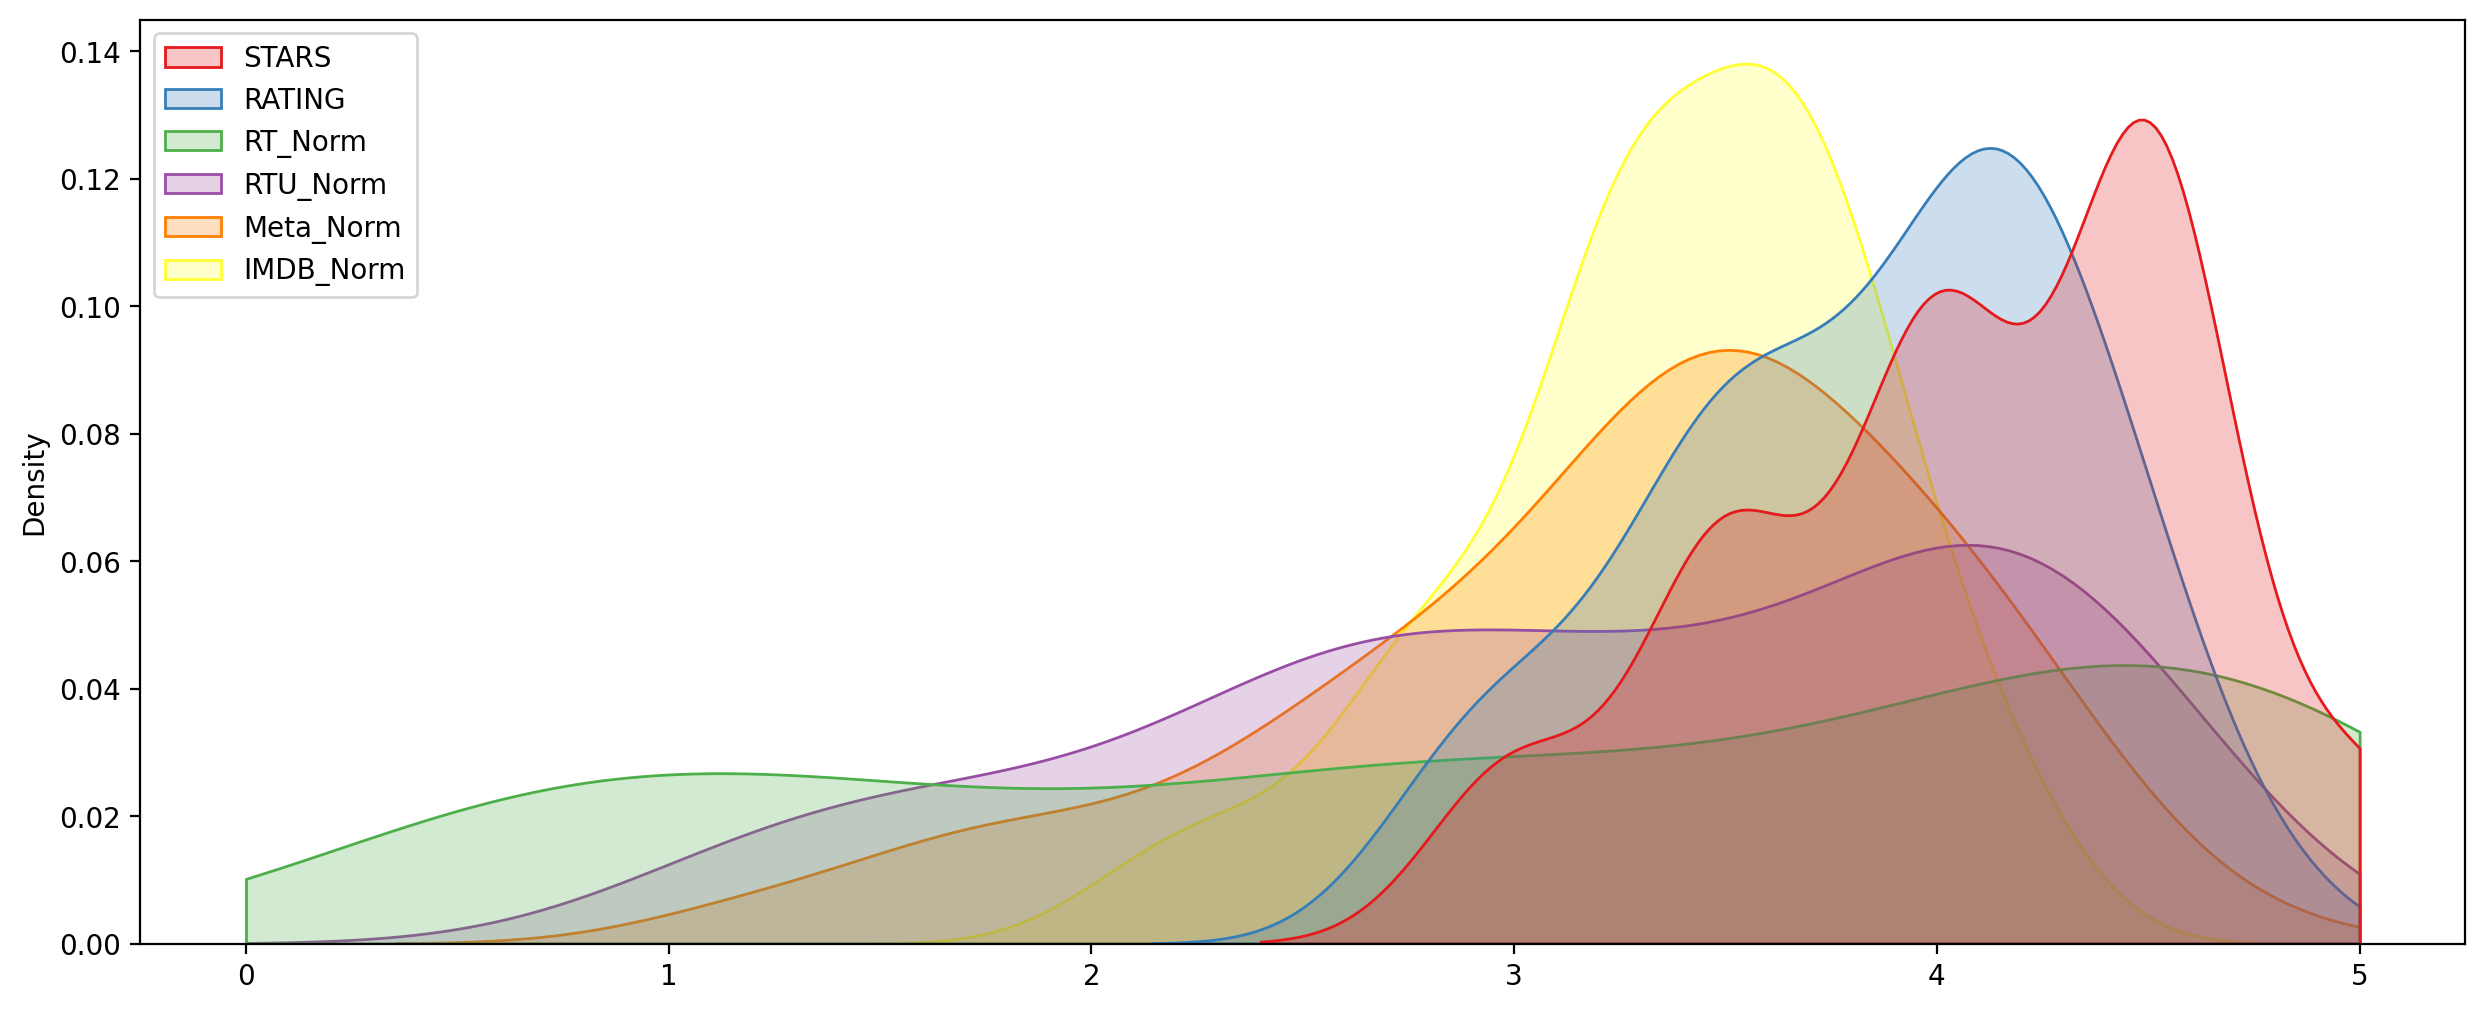

In [109]:
plt.figure(figsize = (15, 6),dpi = 200)
sns.kdeplot(data = norm_scores, fill = True, clip = [0, 5], palette = 'Set1')

**Clearly Fandango has an uneven distribution. We can also see that RT critics have the most uniform distribution. Let's directly compare these two.** 

**I will create a KDE plot that compares the distribution of RT critic ratings against the STARS displayed by Fandango.**

<Axes: ylabel='Density'>

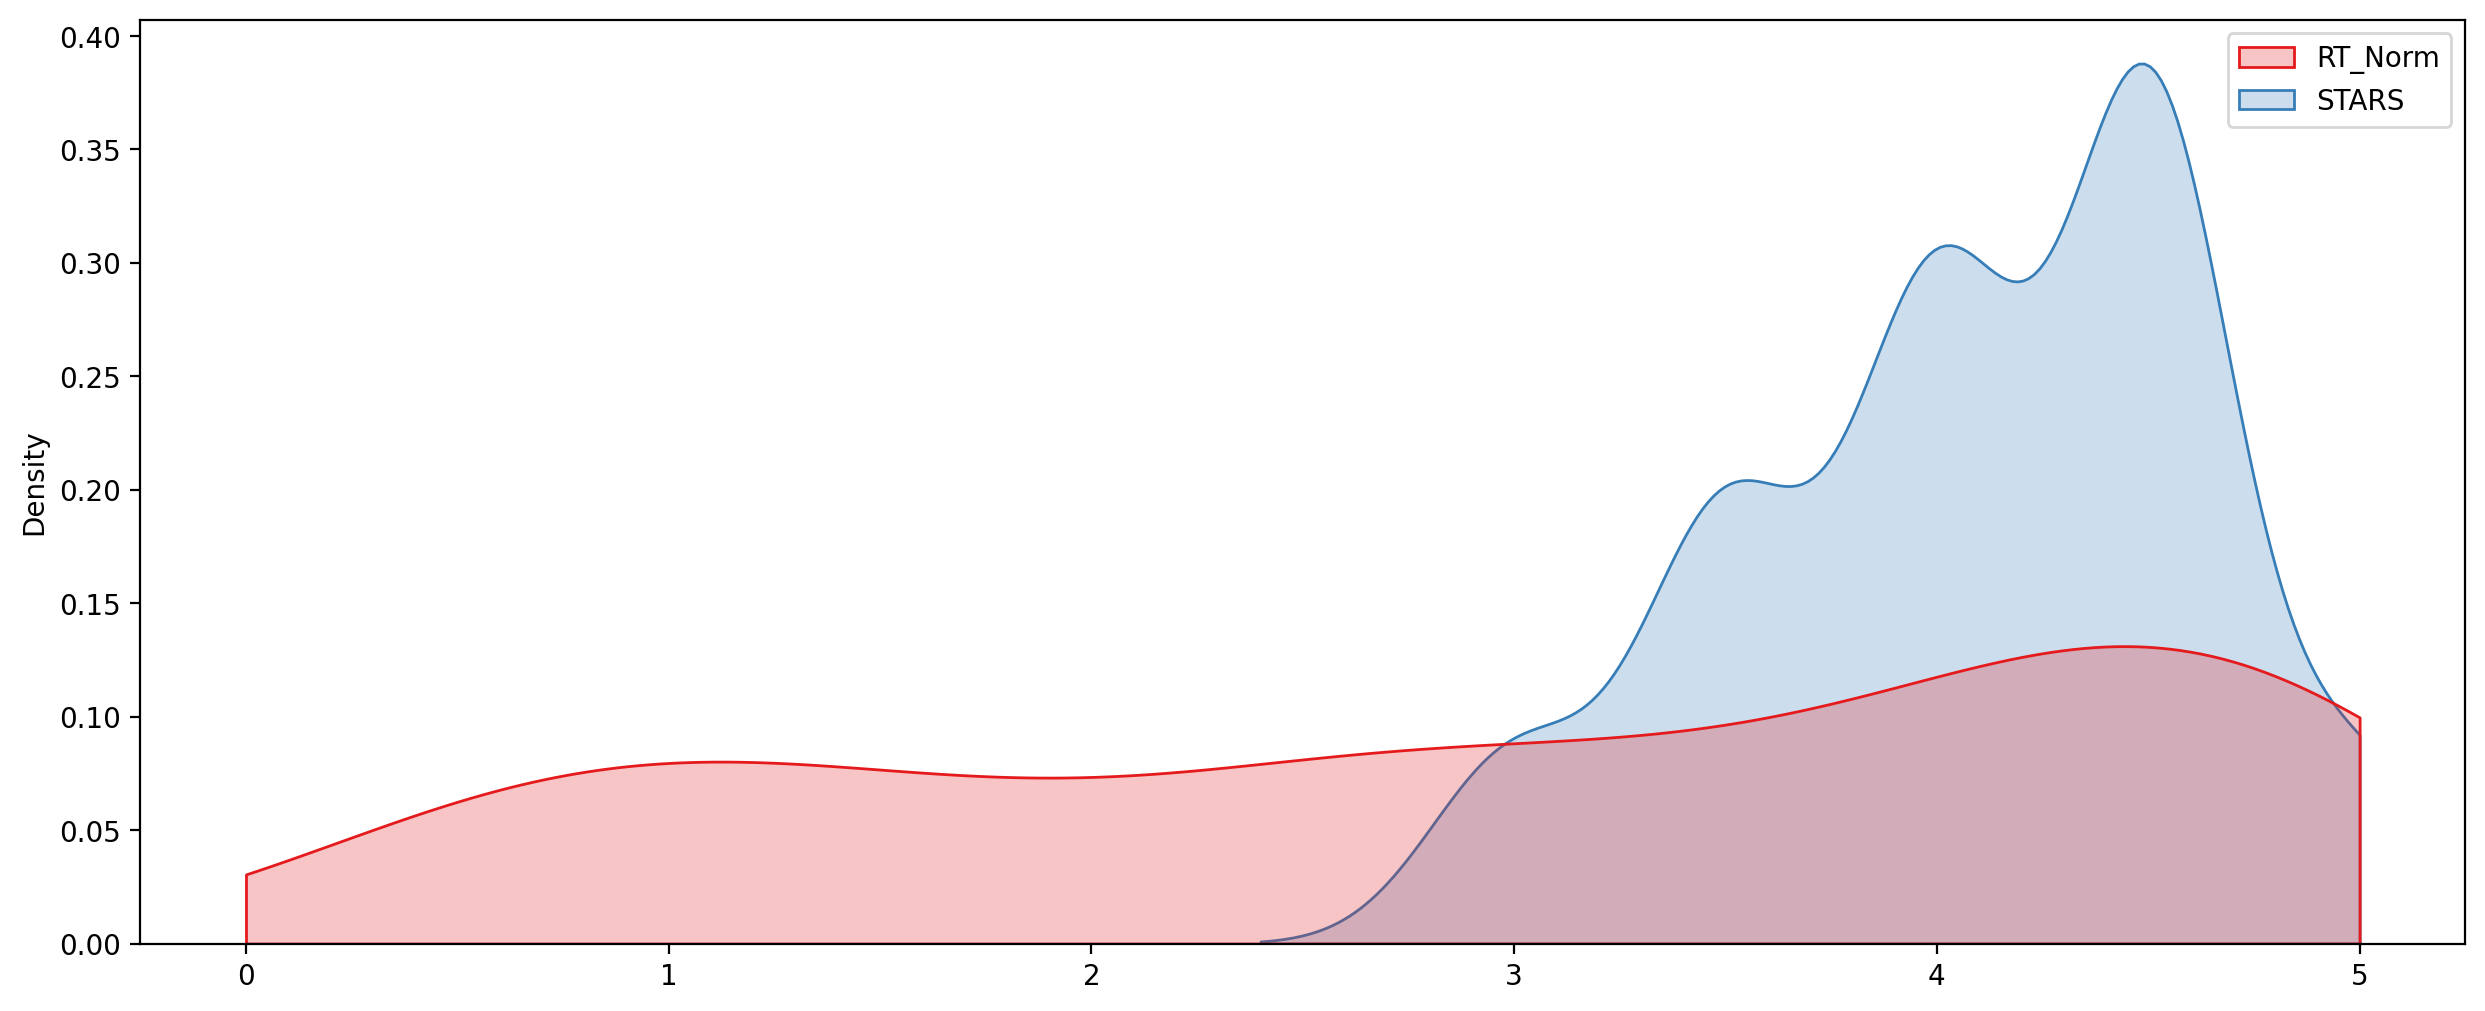

In [111]:
plt.figure(figsize = (15, 6),dpi = 200)
sns.kdeplot(data = norm_scores[['RT_Norm', 'STARS']], fill = True, clip = [0, 5], palette = 'Set1')

----
### How are the worst movies rated across all platforms?

**I will create a clustermap visualization of all normalized scores.**

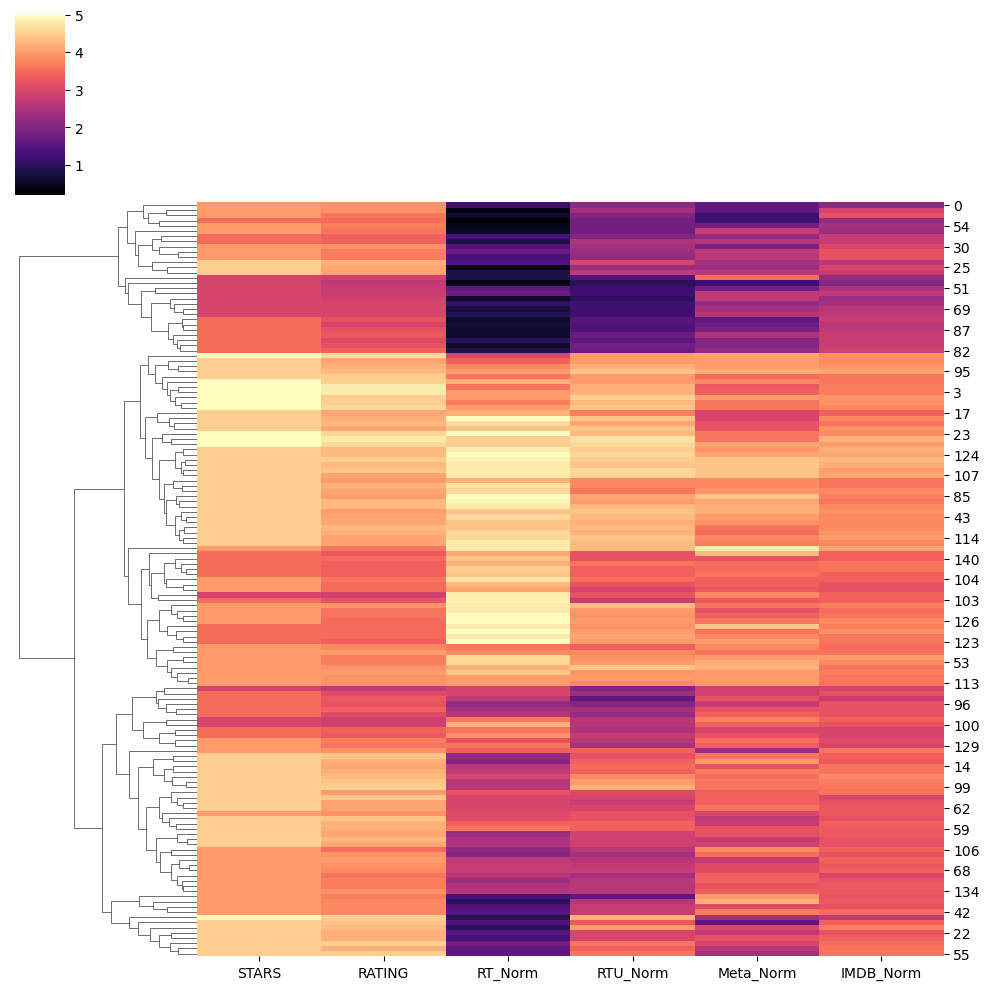

In [113]:
sns.clustermap(norm_scores, cmap = 'magma', col_cluster = False)

**Clearly Fandango is rating movies much higher than other sites, especially considering that it is then displaying a rounded up version of the rating. Let's examine the top 10 worst movies. Based off the Rotten Tomatoes Critic Ratings, what are the top 10 lowest rated movies? What are the normalized scores across all platforms for these movies? These are some good questions to answer**

In [114]:
# Listing out the columns so that I can easily copy paste in the next code
norm_scores.columns

Index(['STARS', 'RATING', 'RT_Norm', 'RTU_Norm', 'Meta_Norm', 'IMDB_Norm'], dtype='object')

In [132]:
# Creating two new tables, norm_films will contain film name and worst_flims will only contain the worst rated ones
norm_films = df[['FILM', 'STARS', 'RATING', 'RT_Norm', 'RTU_Norm', 'Meta_Norm', 'IMDB_Norm']]
worst_films = norm_films.nsmallest(10, 'RT_Norm')

In [120]:
worst_films

,FILM,STARS,RATING,RT_Norm,RTU_Norm,Meta_Norm,IMDB_Norm
49,Paul Blart: Mall Cop 2 (2015),3.5,3.5,0.2,1.8,1.2,2.2
25,Taken 3 (2015),4.5,4.1,0.4,2.3,2.3,3.0
28,Fantastic Four (2015),3.0,2.7,0.4,1.0,1.2,2.0
54,Hot Pursuit (2015),4.0,3.7,0.4,1.8,1.8,2.4
84,Hitman: Agent 47 (2015),4.0,3.9,0.4,2.4,1.6,3.0
50,The Boy Next Door (2015),4.0,3.6,0.5,1.8,2.8,2.3
77,Seventh Son (2015),3.5,3.2,0.6,1.8,2.0,2.8
78,Mortdecai (2015),3.5,3.2,0.6,1.5,1.6,2.8
83,Sinister 2 (2015),3.5,3.3,0.6,1.7,2.5,2.8
87,Unfinished Business (2015),3.5,3.2,0.6,1.4,1.9,2.7


**Visualizing the distribution of ratings across all sites for the top 10 worst movies.**

<Axes: ylabel='Density'>

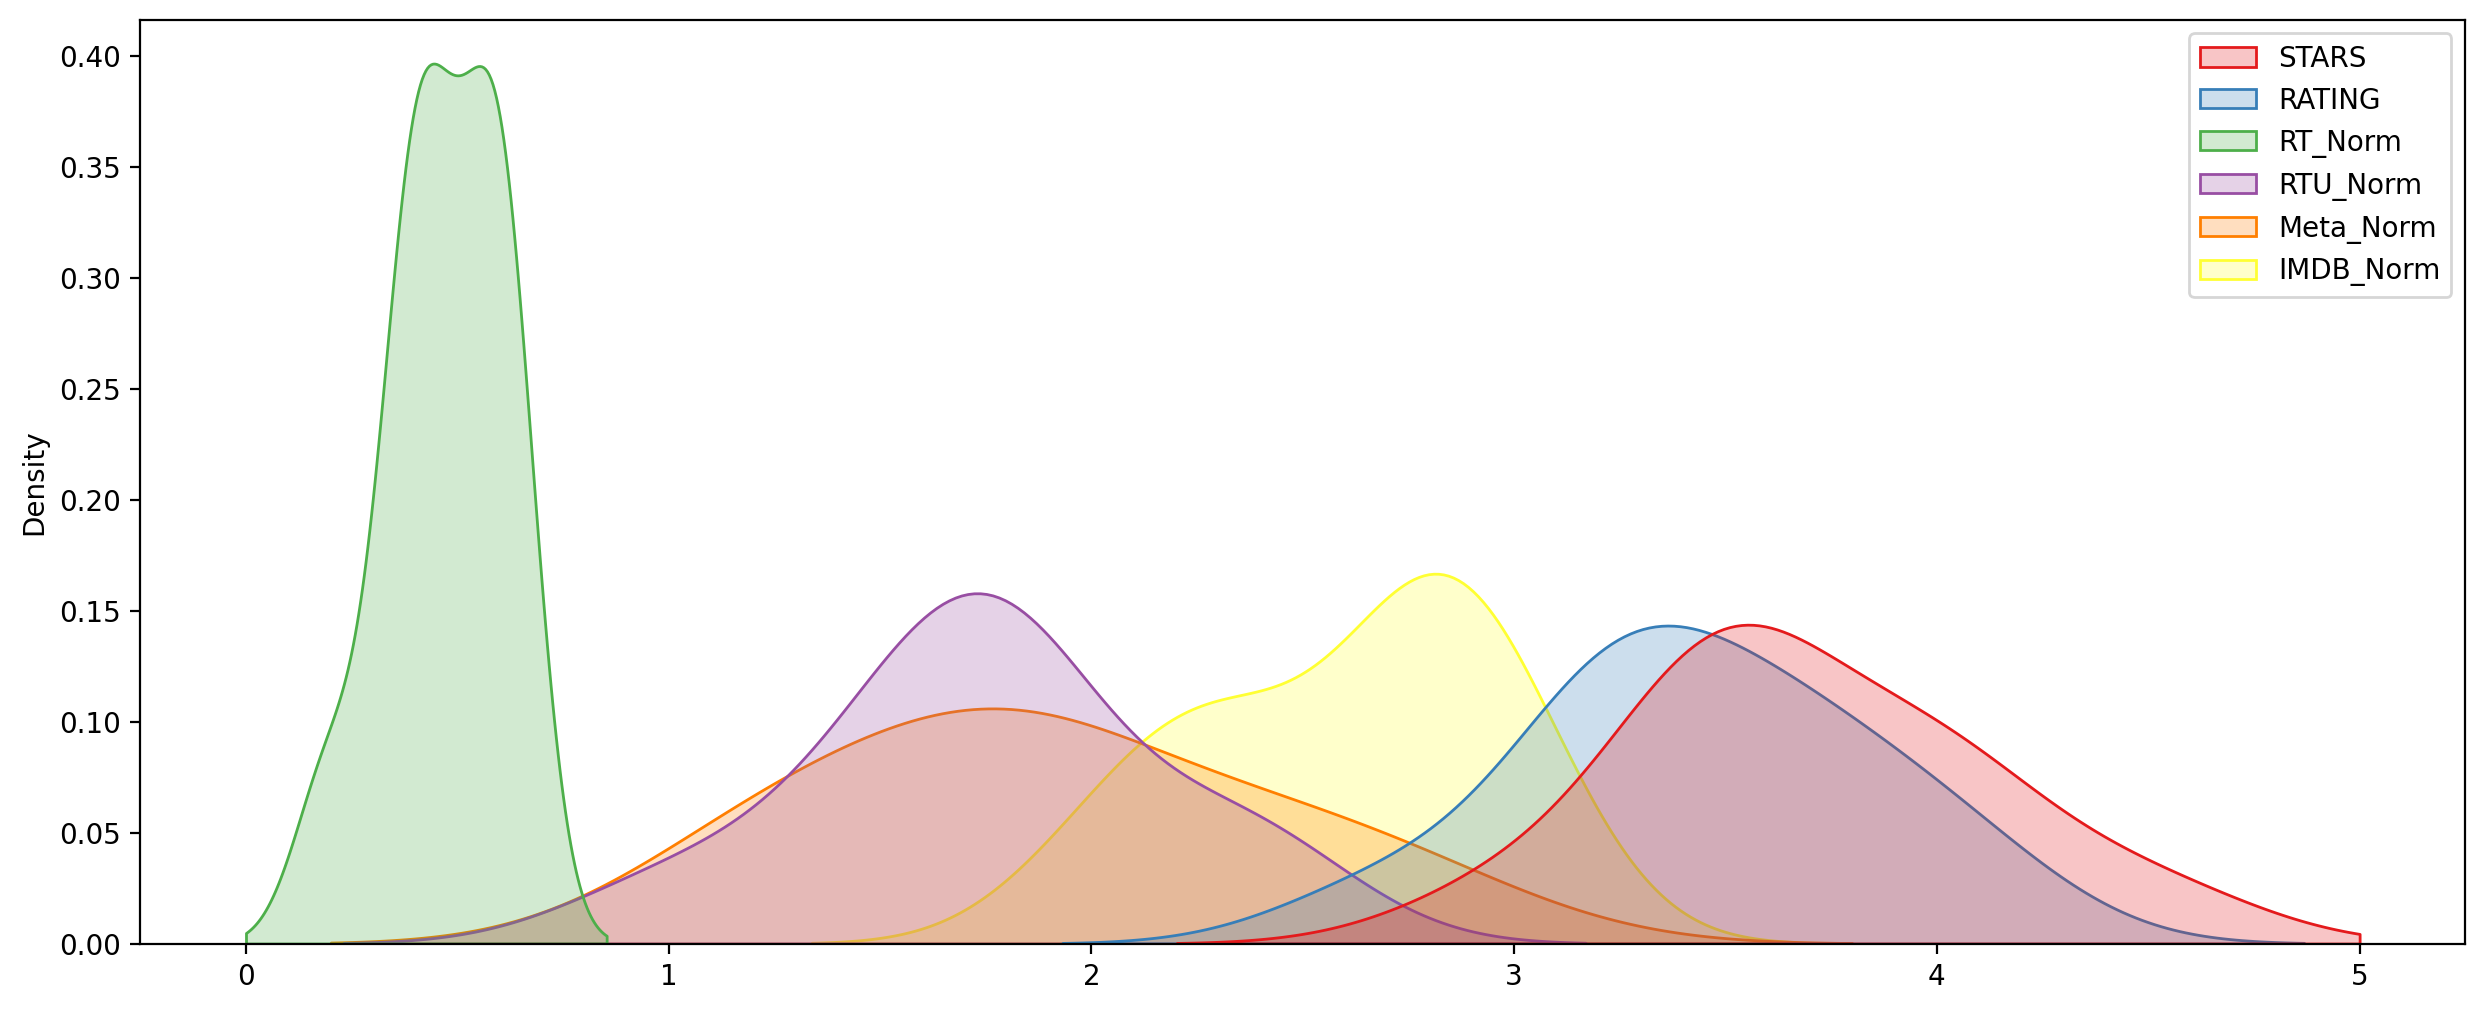

In [121]:
plt.figure(figsize = (15, 6),dpi = 200)
sns.kdeplot(data = worst_films, fill = True, clip = [0, 5], palette = 'Set1')

**Final thoughts: Wow! Fandango is showing around 3-4 star ratings for films that are clearly bad! Notice the biggest offender, [Taken 3!](https://www.youtube.com/watch?v=tJrfImRCHJ0). Fandango is displaying 4.5 stars on their site for a film with an [average rating of 1.86](https://en.wikipedia.org/wiki/Taken_3#Critical_response) across the other platforms!**

In [125]:
worst_films[worst_films['FILM'] =='Taken 3 (2015)']

,FILM,STARS,RATING,RT_Norm,RTU_Norm,Meta_Norm,IMDB_Norm
25,Taken 3 (2015),4.5,4.1,0.4,2.3,2.3,3.0


----